In [ ]:
from google.colab import files  # If using Google Colab
uploaded = files.upload()



Saving Financials.csv to Financials.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load the dataset ---
df = pd.read_csv('Financials.csv')

# Display first few rows to verify
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
      Segment  Country     Product   Discount Band  Units Sold   \
0  Government   Canada   Carretera            None     1,618.50   
1  Government  Germany   Carretera            None     1,321.00   
2   Midmarket   France   Carretera            None     2,178.00   
3   Midmarket  Germany   Carretera            None          888   
4   Midmarket   Mexico   Carretera            None     2,470.00   

    Manufacturing Price    Sale Price   Gross Sales   Discounts      Sales   \
0                      3            20     32,370.00        -     32,370.00   
1                      3            20     26,420.00        -     26,420.00   
2                      3            15     32,670.00        -     32,670.00   
3                      3            15     13,320.00        -     13,320.00   
4                      3            15     37,050.00        -     37,050.00   

       COGS     Profit         Date  Month Number  Month Name   Year  
0  16,185.00  16,185.0

In [5]:
# Check the actual column names in your dataset
print("Actual column names in your CSV:")
print(df.columns.tolist())

Actual column names in your CSV:
['Segment', 'Country', ' Product ', ' Discount Band ', 'Units Sold ', ' Manufacturing Price ', ' Sale Price ', ' Gross Sales ', ' Discounts ', '  Sales ', ' COGS ', ' Profit ', 'Date', 'Month Number', ' Month Name ', 'Year']


In [8]:
# --- CLEAN COLUMN NAMES ---
# Remove extra spaces from column names
df.columns = df.columns.str.strip()
print("Cleaned column names:")
print(df.columns.tolist())
print("\n" + "="*60)

Cleaned column names:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']



In [9]:
# --- INITIAL DATA INSPECTION ---

# 1. Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# 2. Check data types
print("\nData types before cleaning:")
print(df.dtypes)

# 3. Dataset shape
print(f"\nDataset shape: {df.shape}")

Missing values before cleaning:
Segment                 0
Country                 0
Product                 0
Discount Band           0
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
Sales                   0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                   11
dtype: int64

Data types before cleaning:
Segment                object
Country                object
Product                object
Discount Band          object
Units Sold             object
Manufacturing Price     int64
Sale Price              int64
Gross Sales            object
Discounts              object
Sales                  object
COGS                   object
Profit                 object
Date                   object
Month Number            int64
Month Name             object
Year                   object
dtype: object

Dataset shape: 

In [10]:
# --- CONVERT NUMERIC COLUMNS ---
# Remove commas and convert to proper numeric types

numeric_cols = ['Units Sold', 'Manufacturing Price', 'Sale Price',
                'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit']

# Check which columns actually exist
existing_numeric_cols = [col for col in numeric_cols if col in df.columns]
print(f"Numeric columns found: {existing_numeric_cols}")

for col in existing_numeric_cols:
    # Convert to string, remove commas, then convert to numeric
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

print("\nNumeric conversion complete!")

Numeric columns found: ['Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit']

Numeric conversion complete!


In [11]:
# --- HANDLE MISSING VALUES ---

# Drop rows where key financial info is missing
available_cols = [col for col in ['Units Sold', 'Sale Price', 'Profit'] if col in df.columns]

if available_cols:
    initial_rows = len(df)
    df = df.dropna(subset=available_cols)
    print(f"Dropped {initial_rows - len(df)} rows with missing critical data.")
else:
    print("Warning: Could not find expected columns for dropping rows")

# Check missing values again
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Dropped 5 rows with missing critical data.

Missing values after cleaning:
Segment                 0
Country                 0
Product                 0
Discount Band           0
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts              53
Sales                   0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                   11
dtype: int64


In [12]:
# --- CONVERT DATE AND CHECK DUPLICATES ---

# Convert Date column to datetime
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    print("Date column converted successfully.")
    print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

# Check for duplicates
print(f"\nDuplicate records: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

Date column converted successfully.
Date range: 2013-01-09 00:00:00 to 2014-01-12 00:00:00

Duplicate records: 0
Dataset shape after removing duplicates: (695, 16)


In [13]:
# --- FEATURE ENGINEERING: TIME-BASED FEATURES ---

if 'Date' in df.columns:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Month_Name'] = df['Date'].dt.strftime('%B')
    df['Day_of_Week'] = df['Date'].dt.day_name()
    df['Quarter'] = df['Date'].dt.quarter
    print("Time-based features added:")
    print(f"  - Year: {df['Year'].unique()}")
    print(f"  - Months: {df['Month_Name'].unique()}")
    print(f"  - Days: {df['Day_of_Week'].unique()}")

Time-based features added:
  - Year: [2014 2013]
  - Months: ['January']
  - Days: ['Wednesday' 'Monday' 'Sunday' 'Friday' 'Tuesday' 'Thursday' 'Saturday']


In [14]:
# --- FEATURE ENGINEERING: FINANCIAL METRICS ---

# 1. Calculate profit margin (profit as percentage of sales)
if 'Sales' in df.columns and 'Profit' in df.columns:
    df['Profit_Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)
    print("✓ Profit margin calculated")

# 2. Calculate discount rate (discount as percentage of gross sales)
if 'Discounts' in df.columns and 'Gross Sales' in df.columns:
    df['Discount_Rate'] = (df['Discounts'] / df['Gross Sales'] * 100).fillna(0).round(2)
    print("✓ Discount rate calculated")

# 3. Calculate revenue per unit
if 'Sales' in df.columns and 'Units Sold' in df.columns:
    df['Revenue_per_Unit'] = (df['Sales'] / df['Units Sold']).round(2)
    print("✓ Revenue per unit calculated")

# 4. Calculate cost per unit
if 'COGS' in df.columns and 'Units Sold' in df.columns:
    df['Cost_per_Unit'] = (df['COGS'] / df['Units Sold']).round(2)
    print("✓ Cost per unit calculated")

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)

# Display the new columns
new_cols = ['Profit_Margin', 'Discount_Rate', 'Revenue_per_Unit', 'Cost_per_Unit']
existing_new_cols = [col for col in new_cols if col in df.columns]
print(f"\nNew columns added: {existing_new_cols}")

✓ Profit margin calculated
✓ Discount rate calculated
✓ Revenue per unit calculated
✓ Cost per unit calculated

FEATURE ENGINEERING COMPLETE

New columns added: ['Profit_Margin', 'Discount_Rate', 'Revenue_per_Unit', 'Cost_per_Unit']


In [15]:
# --- ANALYSIS 1: TOTAL SALES BY COUNTRY ---

if 'Country' in df.columns and 'Sales' in df.columns:
    country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)

    print("\n" + "="*50)
    print("TOTAL SALES BY COUNTRY")
    print("="*50)
    print(country_sales)

    # Display top country
    top_country = country_sales.index[0]
    top_sales = country_sales.iloc[0]
    print(f"\n Top Country: {top_country} with ${top_sales:,.2f} in sales")


TOTAL SALES BY COUNTRY
Country
United States of America    25029830.18
Canada                      24887654.89
France                      23995612.29
Germany                     23409940.82
Mexico                      20547352.11
Name: Sales, dtype: float64

 Top Country: United States of America with $25,029,830.18 in sales


In [17]:
# --- ANALYSIS 2: TOTAL PROFIT BY PRODUCT ---

if 'Product' in df.columns and 'Profit' in df.columns:
    product_profit = df.groupby('Product')['Profit'].sum().sort_values(ascending=False)

    print("\n" + "="*50)
    print("TOP 10 PRODUCTS BY TOTAL PROFIT")
    print("="*50)
    print(product_profit.head(10))

    # Display top product
    top_product = product_profit.index[0]
    top_profit = product_profit.iloc[0]
    print(f"\n Most Profitable Product: {top_product} with ${top_profit:,.2f} profit")


TOP 10 PRODUCTS BY TOTAL PROFIT
Product
Paseo         4797437.96
VTT           3034608.02
Amarilla      2814104.07
Velo          2305992.47
Montana       2114754.88
Carretera     1826804.89
Name: Profit, dtype: float64

 Most Profitable Product:  Paseo  with $4,797,437.96 profit


In [18]:
# --- ANALYSIS 3: SEGMENT ANALYSIS ---

if 'Segment' in df.columns:
    segment_analysis = df.groupby('Segment').agg({
        'Units Sold': 'sum',
        'Sales': 'sum',
        'Profit': 'sum'
    }).round(2)

    # Add profit margin column to segment analysis
    segment_analysis['Profit_Margin'] = (segment_analysis['Profit'] / segment_analysis['Sales'] * 100).round(2)

    print("\n" + "="*50)
    print("SEGMENT ANALYSIS")
    print("="*50)
    print(segment_analysis)

    # Find best segment
    best_segment = segment_analysis['Profit'].idxmax()
    print(f"\n Best Performing Segment: {best_segment}")


SEGMENT ANALYSIS
                  Units Sold        Sales       Profit  Profit_Margin
Segment                                                              
Channel Partners    161263.5   1800593.64   1316803.14          73.13
Enterprise          161419.0  18755734.38   -614545.62          -3.28
Government          470673.5  52504260.68  11388173.18          21.69
Midmarket           172178.0   2381883.09    660103.09          27.71
Small Business      153139.0  42427918.50   4143168.50           9.77

 Best Performing Segment: Government


In [19]:
# --- ANALYSIS 4: TOP 10 PRODUCTS BY UNITS SOLD ---

if 'Product' in df.columns and 'Units Sold' in df.columns:
    top_products_units = df.groupby('Product')['Units Sold'].sum().nlargest(10)

    print("\n" + "="*50)
    print("TOP 10 BEST-SELLING PRODUCTS (by Units Sold)")
    print("="*50)
    print(top_products_units)

    # Display best seller
    best_seller = top_products_units.index[0]
    best_units = top_products_units.iloc[0]
    print(f"\n Best-Selling Product: {best_seller} with {best_units:,.0f} units sold")


TOP 10 BEST-SELLING PRODUCTS (by Units Sold)
Product
Paseo         333318.5
VTT           168783.0
Velo          162424.5
Amarilla      154241.0
Montana       153060.0
Carretera     146846.0
Name: Units Sold, dtype: float64

 Best-Selling Product:  Paseo  with 333,318 units sold


In [20]:
# --- ANALYSIS 5: SALES BY DISCOUNT BAND ---

if 'Discount Band' in df.columns and 'Sales' in df.columns:
    discount_sales = df.groupby('Discount Band')['Sales'].sum()

    print("\n" + "="*50)
    print("SALES BY DISCOUNT BAND")
    print("="*50)
    print(discount_sales)

    # Calculate percentages
    discount_pct = (discount_sales / discount_sales.sum() * 100).round(1)
    print("\nPercentage breakdown:")
    for band, pct in discount_pct.items():
        print(f"  {band}: {pct}%")


SALES BY DISCOUNT BAND
Discount Band
High       37372486.74
Low        33773818.71
Medium     38780430.84
None        7943654.00
Name: Sales, dtype: float64

Percentage breakdown:
   High : 31.7%
   Low : 28.7%
   Medium : 32.9%
   None : 6.7%


In [21]:
# --- ANALYSIS 6: PROFIT OVER TIME ---

if 'Date' in df.columns and 'Profit' in df.columns:
    profit_over_time = df.groupby(['Year', 'Month', 'Month_Name'])['Profit'].sum().reset_index()
    profit_over_time = profit_over_time.sort_values(['Year', 'Month'])

    print("\n" + "="*50)
    print("PROFIT OVER TIME (Monthly)")
    print("="*50)
    print(profit_over_time.head(12))

    # Find best month
    best_month_row = profit_over_time.loc[profit_over_time['Profit'].idxmax()]
    print(f"\n Best Month: {best_month_row['Month_Name']} {best_month_row['Year']} with ${best_month_row['Profit']:,.2f} profit")


PROFIT OVER TIME (Monthly)
   Year  Month Month_Name       Profit
0  2013      1    January   3878464.51
1  2014      1    January  13015237.78

 Best Month: January 2014 with $13,015,237.78 profit


In [22]:
# --- ANALYSIS 7: TOP 10 PRODUCTS BY AVERAGE PROFIT MARGIN ---

if 'Product' in df.columns and 'Profit_Margin' in df.columns:
    avg_margin_by_product = df.groupby('Product')['Profit_Margin'].mean().nlargest(10)

    print("\n" + "="*50)
    print("TOP 10 PRODUCTS BY AVERAGE PROFIT MARGIN")
    print("="*50)
    print(avg_margin_by_product)

    # Display highest margin
    highest_margin = avg_margin_by_product.index[0]
    margin_value = avg_margin_by_product.iloc[0]
    print(f"\n Highest Profit Margin: {highest_margin} with {margin_value:.1f}% margin")


TOP 10 PRODUCTS BY AVERAGE PROFIT MARGIN
Product
Carretera     29.521935
Amarilla      29.303333
Paseo         28.980804
Montana       27.504239
Velo          26.485596
VTT           26.376422
Name: Profit_Margin, dtype: float64

 Highest Profit Margin:  Carretera  with 29.5% margin


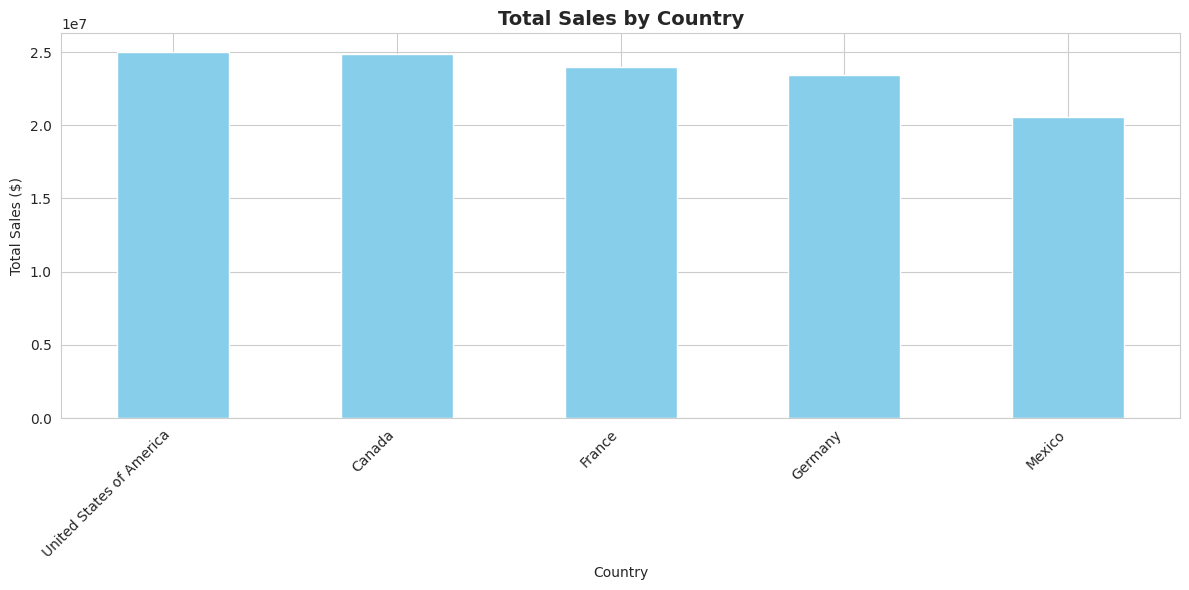

In [23]:
# --- VISUALIZATION 1: TOTAL SALES BY COUNTRY ---

if 'country_sales' in locals() and len(country_sales) > 0:
    plt.figure(figsize=(12, 6))
    country_sales.plot(kind='bar', color='skyblue')
    plt.title('Total Sales by Country', fontsize=14, fontweight='bold')
    plt.xlabel('Country')
    plt.ylabel('Total Sales ($)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Country sales data not available for visualization")

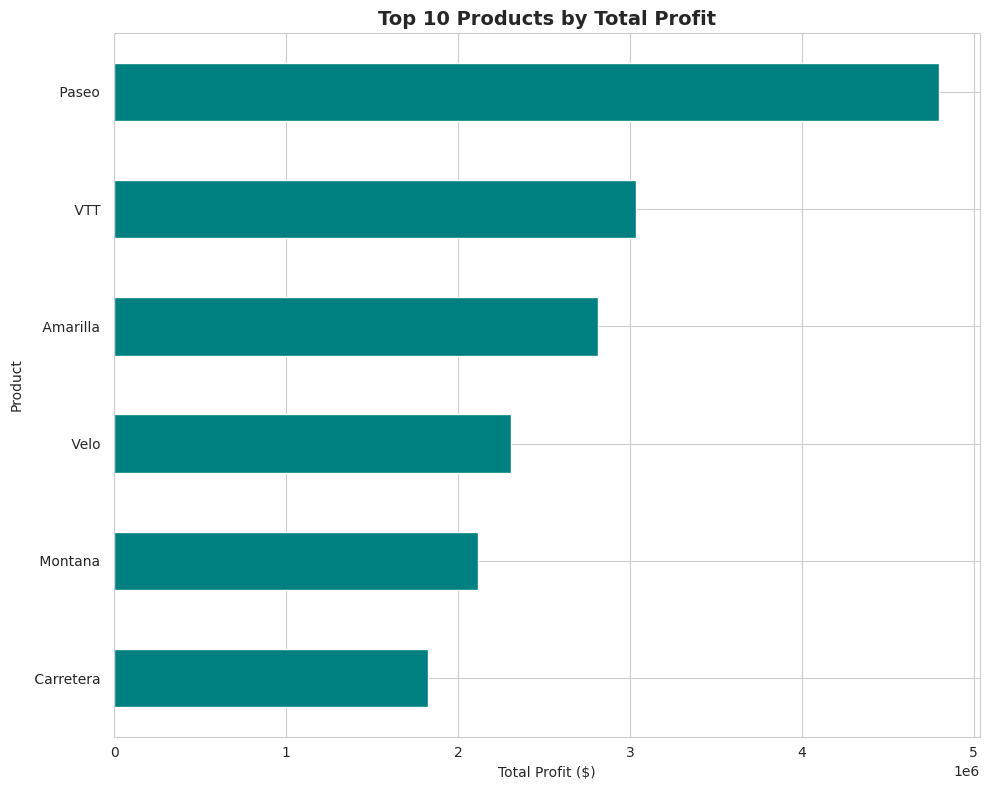

In [24]:
# --- VISUALIZATION 2: TOP 10 PRODUCTS BY PROFIT ---

if 'product_profit' in locals() and len(product_profit) > 0:
    plt.figure(figsize=(10, 8))
    product_profit.head(10).sort_values().plot(kind='barh', color='teal')
    plt.title('Top 10 Products by Total Profit', fontsize=14, fontweight='bold')
    plt.xlabel('Total Profit ($)')
    plt.ylabel('Product')
    plt.tight_layout()
    plt.show()
else:
    print("Product profit data not available for visualization")

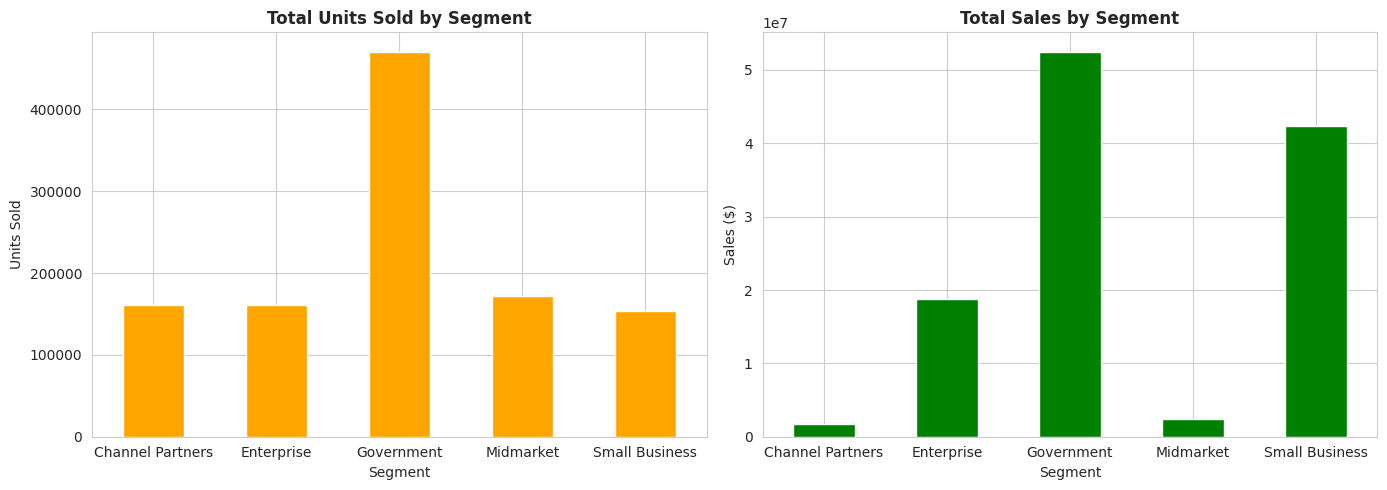

In [ ]:
#  VISUALIZATION 3: SEGMENT ANALYSIS (UNITS SOLD vs SALES)

if 'segment_analysis' in locals() and len(segment_analysis) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if 'Units Sold' in segment_analysis.columns:
        segment_analysis['Units Sold'].plot(kind='bar', ax=axes[0], color='orange')
        axes[0].set_title('Total Units Sold by Segment', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Units Sold')
        axes[0].set_xlabel('Segment')
        axes[0].tick_params(axis='x', rotation=0)

    if 'Sales' in segment_analysis.columns:
        segment_analysis['Sales'].plot(kind='bar', ax=axes[1], color='green')
        axes[1].set_title('Total Sales by Segment', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Sales ($)')
        axes[1].set_xlabel('Segment')
        axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print("Segment analysis data not available for visualization")

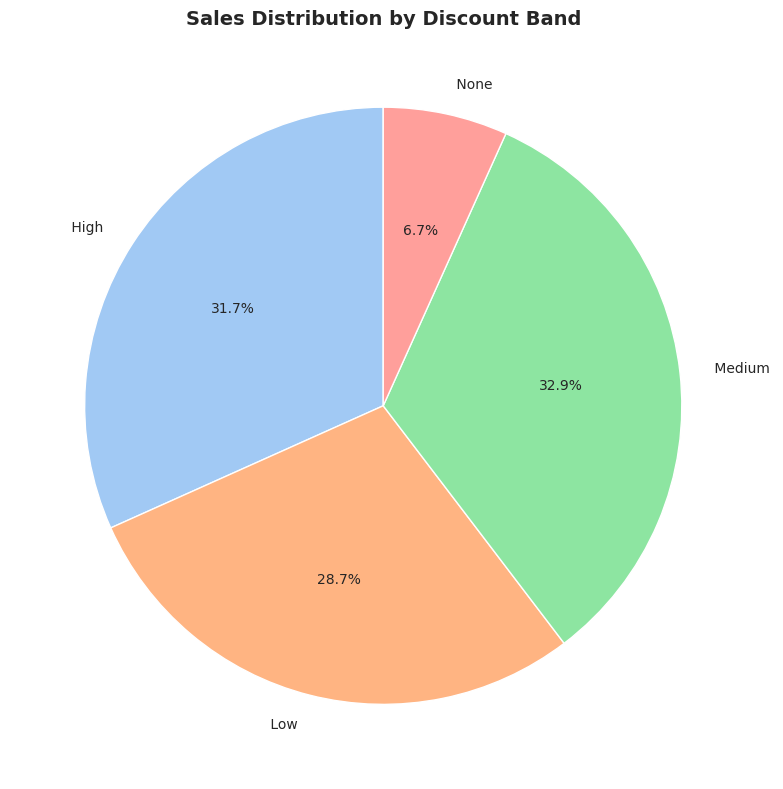

In [26]:
# --- VISUALIZATION 4: SALES DISTRIBUTION BY DISCOUNT BAND ---

if 'discount_sales' in locals() and len(discount_sales) > 0:
    plt.figure(figsize=(8, 8))
    discount_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90,
                        colors=sns.color_palette("pastel"))
    plt.title('Sales Distribution by Discount Band', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print("Discount band data not available for visualization")

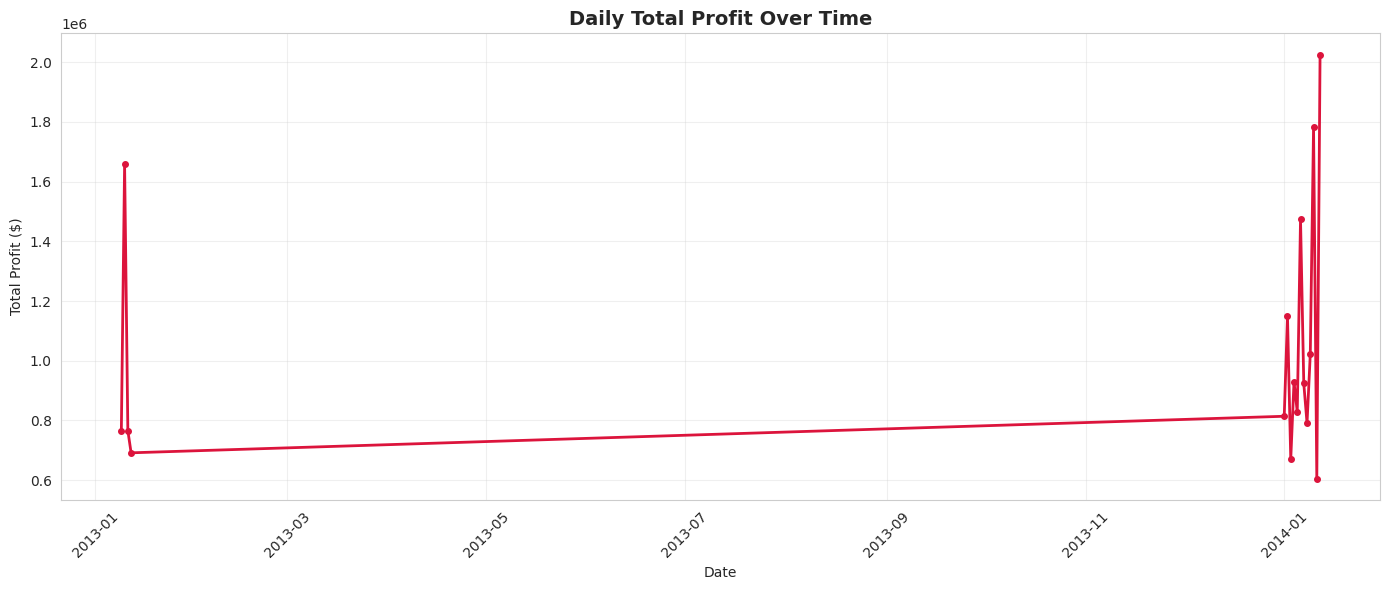

In [27]:
# --- VISUALIZATION 5: PROFIT OVER TIME (LINE CHART) ---

if 'Date' in df.columns and 'Profit' in df.columns:
    profit_time_series = df.groupby('Date')['Profit'].sum().reset_index()
    plt.figure(figsize=(14, 6))
    plt.plot(profit_time_series['Date'], profit_time_series['Profit'],
             marker='o', linewidth=2, markersize=4, color='crimson')
    plt.title('Daily Total Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Total Profit ($)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Profit time series data not available for visualization")

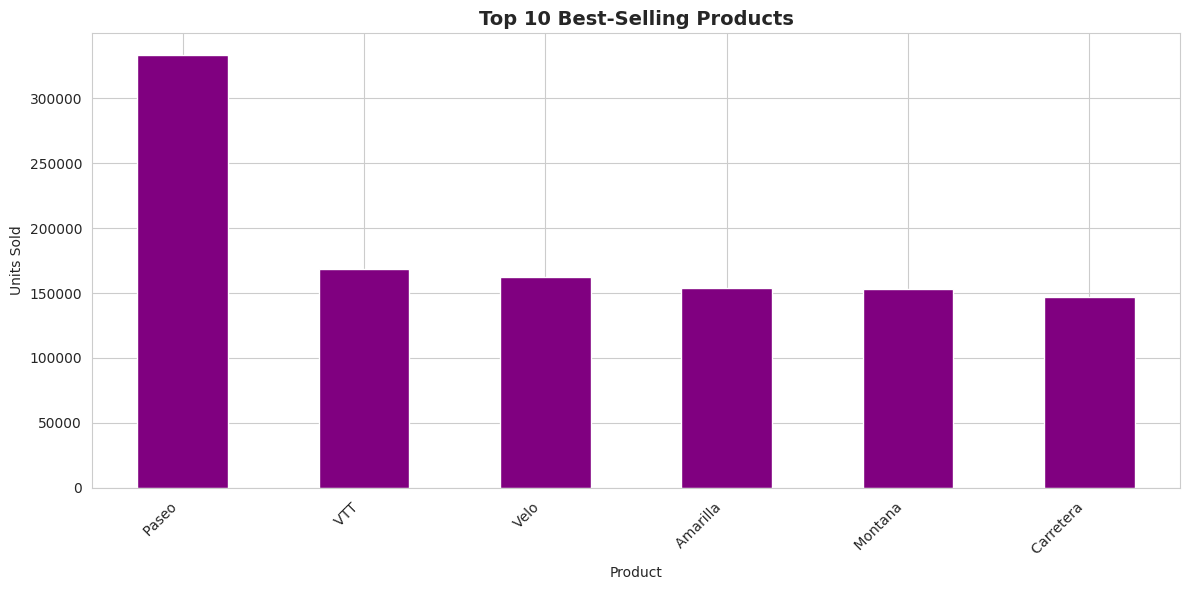

In [28]:
# --- VISUALIZATION 6: TOP 10 BEST-SELLING PRODUCTS ---

if 'top_products_units' in locals() and len(top_products_units) > 0:
    plt.figure(figsize=(12, 6))
    top_products_units.plot(kind='bar', color='purple')
    plt.title('Top 10 Best-Selling Products', fontsize=14, fontweight='bold')
    plt.xlabel('Product')
    plt.ylabel('Units Sold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Top products data not available for visualization")

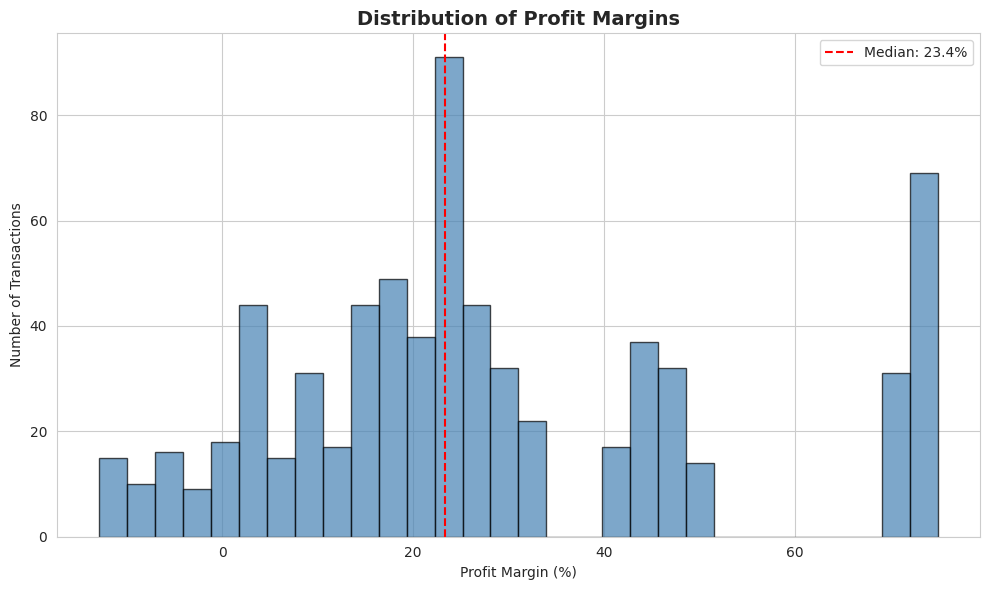

In [29]:
# --- VISUALIZATION 7: PROFIT MARGIN DISTRIBUTION ---

if 'Profit_Margin' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df['Profit_Margin'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title('Distribution of Profit Margins', fontsize=14, fontweight='bold')
    plt.xlabel('Profit Margin (%)')
    plt.ylabel('Number of Transactions')

    if df['Profit_Margin'].notna().any():
        plt.axvline(df['Profit_Margin'].median(), color='red', linestyle='--',
                    label=f'Median: {df["Profit_Margin"].median():.1f}%')
        plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Profit margin data not available for visualization")